# Importing Necessary Libraries
In this section, we import all the libraries required for data manipulation, text preprocessing, and model training. Each library serves a specific purpose:
- **NumPy**: For numerical operations.
- **Pandas**: For data manipulation and analysis.
- **NLTK**: For natural language processing tasks like tokenization, stopword removal, and lemmatization.
- **Scikit-learn**: For feature extraction, model training, and evaluation.

In [168]:
# Importing necessary libraries
import numpy as np  # for numerical operations
import pandas as pd  # for data manipulation
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for advanced plotting 

import random  # for shuffling the data
import re  # for handling regular expressions

import nltk # for natural language processing
from nltk.stem import WordNetLemmatizer  # for lemmatizing words
from nltk.corpus import stopwords  # for stop word removal
from nltk.tokenize import word_tokenize  # for tokenizing sentences into words

# Downloading necessary NLTK resources
nltk.download('stopwords')  # List of common stop words in English
nltk.download('punkt')  # Pre-trained tokenizer models
nltk.download('wordnet')  # WordNet lemmatizer dataset
nltk.download('punkt_tab')  # Downloads the 'punkt' tokenizer table used for tokenization of text into sentences or words

# Libraries for text feature extraction and model training
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text into numerical features (TF-IDF)
from sklearn.linear_model import LogisticRegression  # Logistic regression for classification
from sklearn.svm import LinearSVC  # Support Vector Machines for classification

# Libraries for model evaluation and validation 
from sklearn.model_selection import train_test_split  # Import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  # For model evaluation metrics
from sklearn.model_selection import KFold, cross_val_score  # For cross-validation
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/zeal.v/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/zeal.v/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/zeal.v/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/zeal.v/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Loading the Dataset
Here, we load the IMDb Reviews dataset, which contains movie reviews and their corresponding sentiment labels (positive or negative).

The dataset is loaded into a Pandas DataFrame for easy manipulation and analysis.

In [169]:
# Specify the file path to the dataset
file_path = '/Users/zeal.v/Desktop/Mini_NLP_Project-Masterschool_Final_Mock_Interview/DATA/IMDb_Reviews.csv'  # Path to the dataset

# Load the dataset into a pandas DataFrame
dataset = pd.read_csv(file_path)  # Load the dataset

# Display the first few rows of the dataset to understand its structure
dataset.head()

,review,sentiment
0,My family and I normally do not watch local mo...,1
1,"Believe it or not, this was at one time the wo...",0
2,"After some internet surfing, I found the ""Home...",0
3,One of the most unheralded great works of anim...,1
4,"It was the Sixties, and anyone with long hair ...",0


# Preprocessing the Text Data
Text preprocessing is a crucial step in natural language processing. It involves cleaning and preparing the text data to make it suitable for analysis. The steps include:
- **Lowercasing**: Converting text to lowercase to ensure uniformity.
- **Removing Special Characters**: Eliminating punctuation and other non-alphanumeric characters.
- **Tokenization**: Splitting text into individual words.
- **Stopword Removal**: Removing common words that do not contribute to the sentiment (e.g., 'and', 'the').
- **Lemmatization**: Reducing words to their base or root form (e.g., 'running' becomes 'run').

The cleaned text is stored in a new column named `cleaned_review`.

In [170]:
# Function to preprocess text data
def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove numbers
    text = re.sub(r'\d+', '', text)
     # Remove punctuation  
    text = re.sub(r'[^\w\s]', '', text) 
    
    # Tokenize the text into words
    words = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    
    # Apply lemmatization
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # Join the words back into a single string
    return ' '.join(words)

# Apply preprocessing to the 'review' column
dataset['cleaned_review'] = dataset['review'].apply(preprocess_text)

# Display the first few rows of the dataset to verify the new column
dataset.head()

,review,sentiment,cleaned_review
0,My family and I normally do not watch local mo...,1,family normally watch local movie simple reaso...
1,"Believe it or not, this was at one time the wo...",0,believe one time worst movie ever seen since t...
2,"After some internet surfing, I found the ""Home...",0,internet surfing found homefront series dvd io...
3,One of the most unheralded great works of anim...,1,one unheralded great work animation though mak...
4,"It was the Sixties, and anyone with long hair ...",0,sixty anyone long hair hip distant attitude co...


# Verifying Sentiment Mapping
To confirm that `1` represents positive and `0` represents negative, we will display a few rows of the dataset, including both the 'review' and 'sentiment' columns. This will help us verify the alignment between the review text and sentiment labels.

In [171]:
# Display a few rows of the dataset to verify sentiment mapping
print(dataset[['review', 'sentiment']].head(10))

                                              review  sentiment
0  My family and I normally do not watch local mo...          1
1  Believe it or not, this was at one time the wo...          0
2  After some internet surfing, I found the "Home...          0
3  One of the most unheralded great works of anim...          1
4  It was the Sixties, and anyone with long hair ...          0
5  For my humanities quarter project for school, ...          1
6  Arguebly Al Pacino's best role. He plays Tony ...          1
7  Being a big fan of Stanley Kubrick's Clockwork...          1
8  I reached the end of this and I was almost sho...          1
9  There is no doubt that Halloween is by far one...          1


## Exploratory Data Analysis (EDA)
We will explore the dataset to identify patterns and insights, such as:
- Review length and its correlation with sentiment.
- Frequent keywords in positive and negative reviews.
- Mixed sentiments in reviews.

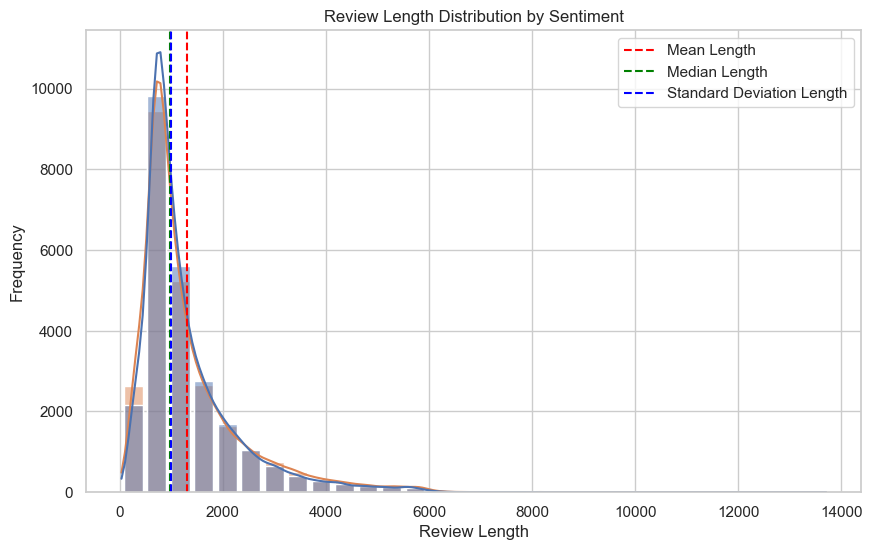

In [172]:
dataset['review_length'] = dataset['review'].apply(len)  # len counts characters

# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=dataset, x='review_length', hue='sentiment', bins=30, kde=True, shrink=0.8)  # Use shrink to add space between bins
plt.title('Review Length Distribution by Sentiment')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.axvline(dataset['review_length'].mean(), color='red', linestyle='--', label='Mean Length')  # Add a vertical line for mean length
plt.axvline(dataset['review_length'].median(), color='green', linestyle='--', label='Median Length')  # Add a vertical line for median length
plt.axvline(dataset['review_length'].std(), color='blue', linestyle='--', label='Standard Deviation Length')  # Add a vertical line for standard deviation length
plt.legend()
plt.show()

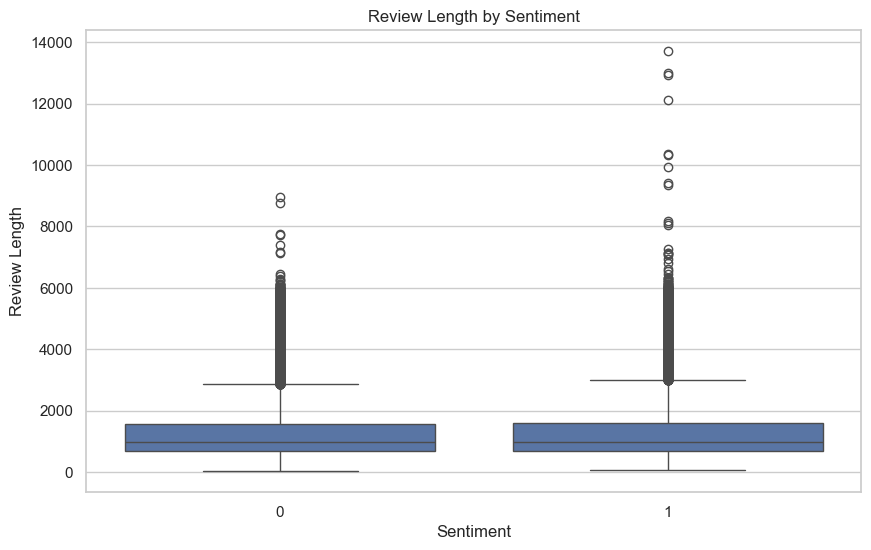

In [173]:
# Analyze review lengths by sentiment with boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset, x='sentiment', y='review_length')
plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.show()

#### Following code snippet uses the Counter class from Python's collections module to count the frequency of words in a collection of positive reviews. Here's a breakdown of its functionality:

- Joining Positive Reviews: The join method combines all the strings in the positive_reviews collection into a single string, with each review separated by a space. This creates a unified text representation of all positive reviews.

- Splitting into Words: The split method then breaks this unified string into individual words based on spaces. This results in a list of words from all the positive reviews.

- Counting Word Frequencies: The Counter class takes this list of words as input and creates a dictionary-like object where the keys are unique words, and the values are their respective counts. This allows for quick access to the frequency of any word in the positive reviews.

- This approach is particularly useful for identifying the most common words in positive reviews, which can provide insights into recurring themes or sentiments expressed by customers. For example, frequently occurring words like "delicious," "friendly," or "excellent" might highlight aspects of the service or product that customers appreciate the most.

In [174]:
# Extract frequent keywords
from collections import Counter
positive_reviews = dataset[dataset['sentiment'] == 1]['cleaned_review']
negative_reviews = dataset[dataset['sentiment'] == 0]['cleaned_review']

positive_words = Counter(' '.join(positive_reviews).split())
negative_words = Counter(' '.join(negative_reviews).split())

print('Most common words in positive reviews:', positive_words.most_common(20))
print('Most common words in negative reviews:', negative_words.most_common(20))

Most common words in positive reviews: [('br', 55875), ('film', 47871), ('movie', 43118), ('one', 27317), ('like', 17629), ('time', 15187), ('good', 14459), ('story', 13664), ('character', 13638), ('great', 12780), ('see', 12593), ('well', 11220), ('get', 11107), ('make', 11001), ('also', 10704), ('really', 10696), ('would', 10377), ('scene', 9687), ('even', 9482), ('show', 9416)]
Most common words in negative reviews: [('br', 59002), ('movie', 55859), ('film', 41879), ('one', 25994), ('like', 22318), ('even', 15095), ('good', 14224), ('time', 14171), ('bad', 14132), ('character', 13961), ('would', 13647), ('get', 13347), ('make', 12593), ('really', 12255), ('scene', 11018), ('see', 10999), ('story', 10601), ('dont', 10266), ('much', 9914), ('people', 9370)]


In [175]:
# Display the review for example at index 104
print(dataset.iloc[104][['review', 'sentiment']])

review       be warned: this movie tells lots of love stori...
sentiment                                                    0
Name: 104, dtype: object


In [176]:
# Display the distribution of sentiments in the dataset
print(dataset['sentiment'].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


## Train-Test Split
To evaluate the performance of our models, we split the dataset into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [177]:
# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Training data shape: (40000,), Training labels shape: (40000,)
Testing data shape: (10000,), Testing labels shape: (10000,)


In [178]:
# Initialize the TF-IDF vectorizer with stopwords
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to 5000 features and exclude stopwords
# Fit and transform the features
X_vectorized = vectorizer.fit_transform(X)  # Convert text to TF-IDF features
# Display the shape of the vectorized features
print(X_vectorized.shape)  # Display the shape of the vectorized features
# Display the first few rows of the vectorized features
print(X_vectorized.toarray()[:5])  # Display the first few rows of the vectorized features


(50000, 5000)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [179]:
# Convert the TF-IDF matrix to a DataFrame for better visualization
X_df = pd.DataFrame(X_vectorized.toarray(), columns=vectorizer.get_feature_names_out())
'''Dense Array: The toarray() method converts the sparse matrix into a dense NumPy array.
In this format, all elements (including zeros) are explicitly stored, 
making it suitable for use in pandas DataFrames or other tools that require dense data.'''
  # Convert to DataFrame
# Display the first few rows of the DataFrame
X_df.head()  # Display the first few rows of the DataFrame 
# Display the first few rows of the original dataset
dataset.head()  # Display the first few rows of the original dataset 

,review,sentiment,cleaned_review,review_length
0,My family and I normally do not watch local mo...,1,family normally watch local movie simple reaso...,758
1,"Believe it or not, this was at one time the wo...",0,believe one time worst movie ever seen since t...,244
2,"After some internet surfing, I found the ""Home...",0,internet surfing found homefront series dvd io...,5129
3,One of the most unheralded great works of anim...,1,one unheralded great work animation though mak...,444
4,"It was the Sixties, and anyone with long hair ...",0,sixty anyone long hair hip distant attitude co...,3494


In [180]:
# Train a `MultinomialNB` model using the transformed text data.
from sklearn.naive_bayes import MultinomialNB  # Importing Multinomial Naive Bayes classifier
# Initialize the Multinomial Naive Bayes classifier
model = MultinomialNB()  # Initialize the model
# Fit the model to the training data
model.fit(X_vectorized, y)  # Train the model
# Make predictions on the training data
y_pred = model.predict(X_vectorized)  # Predict sentiments
# Display the first few predictions
print(y_pred[:10])  # Display the first few predictions
# Display the first few actual sentiments
print(y[:10])  # Display the first few actual sentiments 


[0 0 0 0 1 1 1 1 1 1]
0    0
1    0
2    1
3    0
4    1
5    1
6    0
7    1
8    1
9    1
Name: sentiment, dtype: int64


In [ ]:
# Display the accuracy score of the model on the training data 
print(accuracy_score(y, y_pred))

0.86042


In [186]:
# Display the confusion matrix 
print(confusion_matrix(y, y_pred))

[[21397  3603]
 [ 3376 21624]]


In [181]:
# Display the classification report
print(classification_report(y, y_pred))  # Display the classification report

              precision    recall  f1-score   support

           0       0.86      0.86      0.86     25000
           1       0.86      0.86      0.86     25000

    accuracy                           0.86     50000
   macro avg       0.86      0.86      0.86     50000
weighted avg       0.86      0.86      0.86     50000



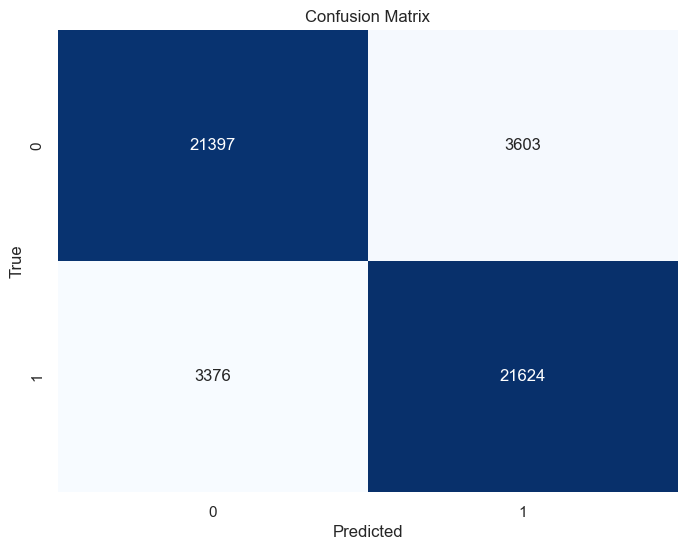

In [182]:
# Create a confusion matrix
cm = confusion_matrix(y, y_pred)  # Compute the confusion matrix
# Plot the confusion matrix
plt.figure(figsize=(8, 6))  # Set the figure size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)  # Plot the confusion matrix
plt.xlabel('Predicted')  # Set x-axis label
plt.ylabel('True')  # Set y-axis label
plt.title('Confusion Matrix')  # Set title
plt.show()  # Show the plot

## Mathematical Formulas in LaTeX
To better understand the evaluation metrics, here are the mathematical formulas written in LaTeX:

### 1. Accuracy
$$\text{Accuracy} = \frac{\text{True Positives} + \text{True Negatives}}{\text{Total Samples}}$$

### 2. Precision
$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$

### 3. Recall (Sensitivity or True Positive Rate)
$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$

### 4. F1-Score
$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

These formulas provide a clear mathematical representation of how each metric is calculated.

## Expanded Explanation of Model Evaluation Metrics
To deeply understand how our models perform, let's break down the evaluation metrics in more detail:

### 1. Accuracy
- **What it measures**: Accuracy tells us the percentage of total predictions (both positive and negative) that the model got correct.
- **Formula**: Accuracy = (True Positives + True Negatives) / Total Samples
- **When it's useful**: Accuracy is a good metric when the dataset is balanced, meaning there are roughly equal numbers of positive and negative reviews.
- **Limitations**: If the dataset is imbalanced (e.g., 90% positive reviews and 10% negative), a model that always predicts 'positive' will have high accuracy but will fail to identify negative reviews.

### 2. Precision
- **What it measures**: Precision focuses on the quality of positive predictions. It answers the question: 'Of all the reviews the model predicted as positive, how many were actually positive?'
- **Formula**: Precision = True Positives / (True Positives + False Positives)
- **When it's useful**: Precision is important when false positives are costly. For example, in a business setting, falsely labeling a negative review as positive might lead to ignoring critical customer feedback.

### 3. Recall (Sensitivity or True Positive Rate)
- **What it measures**: Recall focuses on the model's ability to find all positive reviews. It answers the question: 'Of all the actual positive reviews, how many did the model correctly identify?'
- **Formula**: Recall = True Positives / (True Positives + False Negatives)
- **When it's useful**: Recall is crucial when missing positive reviews is costly. For example, if positive reviews are used to identify satisfied customers for loyalty programs, missing them could lead to lost opportunities.

### 4. F1-Score
- **What it measures**: The F1-score is the harmonic mean of precision and recall. It provides a single metric that balances the trade-off between precision and recall.
- **Formula**: F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
- **When it's useful**: The F1-score is particularly useful when the dataset is imbalanced, as it considers both false positives and false negatives.

### Example to Illustrate Metrics
Imagine we have 100 reviews, 80 positive and 20 negative. The model predicts 85 as positive and 15 as negative. Out of the 85 positive predictions, 75 are correct (true positives), and 10 are incorrect (false positives). Out of the 15 negative predictions, 10 are correct (true negatives), and 5 are incorrect (false negatives).

- **Accuracy**: (75 + 10) / 100 = 85%
- **Precision**: 75 / (75 + 10) = 88.2%
- **Recall**: 75 / (75 + 5) = 93.8%
- **F1-Score**: 2 * (0.882 * 0.938) / (0.882 + 0.938) ≈ 91%

### Observations for Logistic Regression and SVM
- **Logistic Regression**: This model is simple and interpretable. It works well when the relationship between features and the target is linear. If its precision is higher than recall, it means the model is conservative in predicting positive reviews, avoiding false positives but potentially missing some true positives.
- **SVM**: Support Vector Machines are powerful for high-dimensional data. If its recall is higher than precision, it means the model is aggressive in predicting positive reviews, capturing more true positives but at the cost of more false positives.

By comparing these metrics, we can decide which model aligns better with the business goals. For example, if identifying all positive reviews is critical, we might prioritize recall over precision.